In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import time

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"]= str(5)

In [3]:
# model = torch.hub.load("serizba/salad", "dinov2_salad")
model = torch.hub.load("amaralibey/bag-of-queries", "get_trained_boq", backbone_name='dinov2', output_dim=12288)
print(model.num_trainable_blocks)

Using cache found in /home/osverburg/.cache/torch/hub/amaralibey_bag-of-queries_main
Using cache found in /home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main
/home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


AttributeError: 'VPRModel' object has no attribute 'num_trainable_blocks'

In [5]:
print(model.backbone.num_unfrozen_blocks)

2


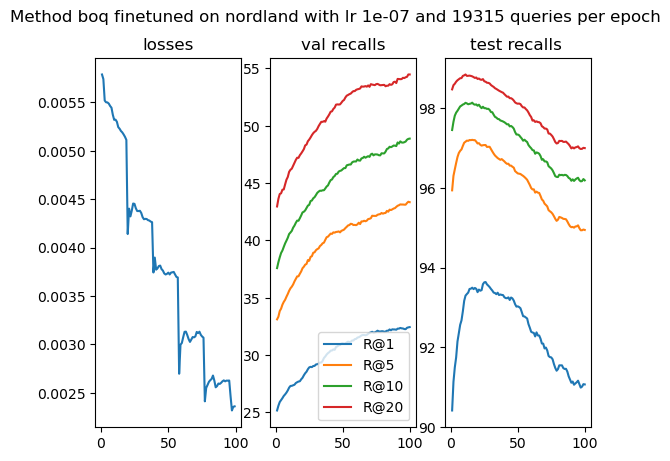

test recalls were [91.0771238  94.9514352  96.21629458 96.99913018] for the highest validation R@5
Original model results were [90.41751232 95.93360394 97.44491157 98.4633227 ] 
6
19315
average epoch took4:39:44.288395 and median: 4:46:49.897989
training backbone: original with model.eval
training aggregator: True
augmentations: True


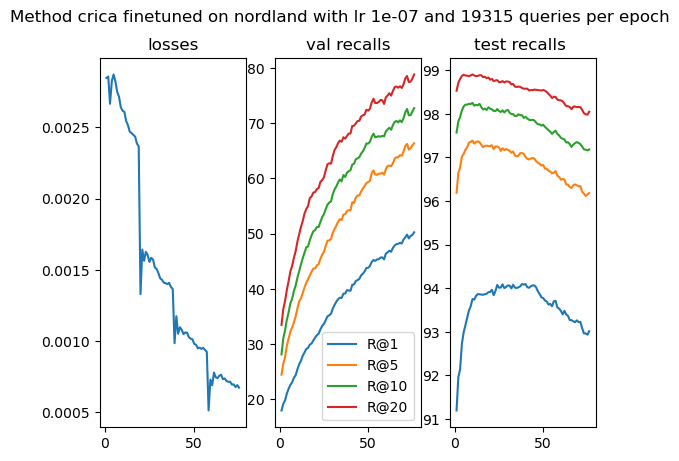

test recalls were [93.01246738 96.18367643 97.18396637 98.05015947] for the highest validation R@5
Original model results were [91.19309945 96.19092491 97.57175993 98.53218324] 
7
19315
average epoch took2:29:58.138117 and median: 2:28:20.005726
training backbone: original with model.eval
training aggregator: True
augmentations: True


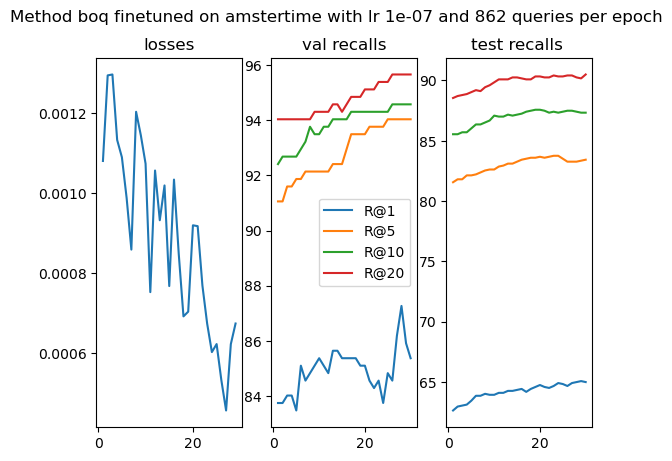

test recalls were [64.82534525 83.509342   87.40861089 90.33306255] for the highest validation R@5
Original model results were [62.6320065  81.55970755 85.54021121 88.54589764] 
7
862
average epoch took0:02:18.915246 and median: 0:02:16.237020
training backbone: original with model.eval
training aggregator: True
augmentations: True


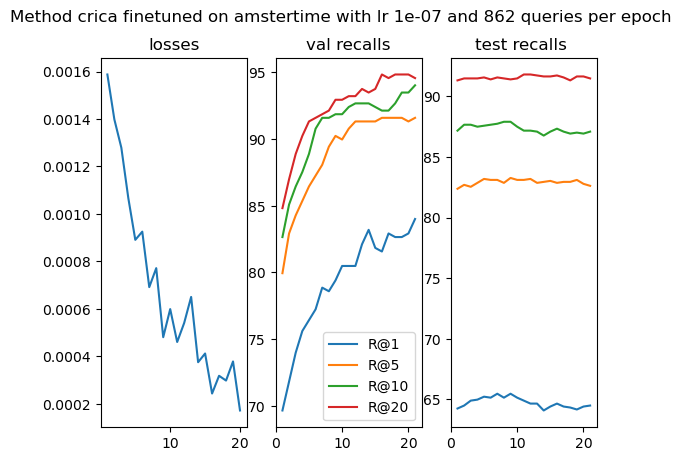

test recalls were [64.66287571 82.85946385 87.32737612 91.71405361] for the highest validation R@5
Original model results were [64.25670187 82.37205524 87.16490658 91.30787977] 
7
862
average epoch took0:01:53.362074 and median: 0:01:50.724934
training backbone: original with model.eval
training aggregator: True
augmentations: True


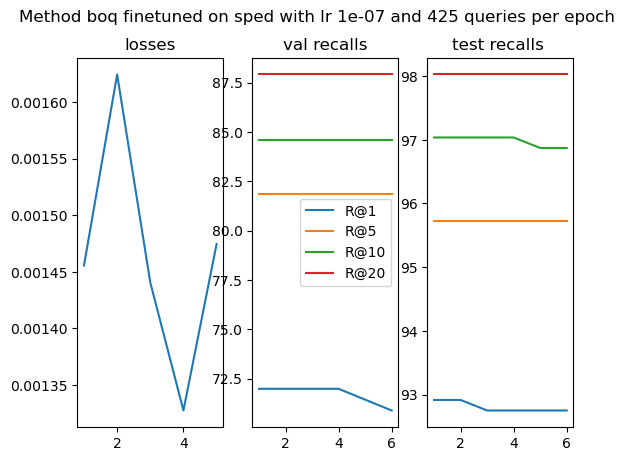

test recalls were [92.91598023 95.71663921 97.03459638 98.02306425] for the highest validation R@5
Original model results were [92.91598023 95.71663921 97.03459638 98.02306425] 
7
425
average epoch took0:01:15.578415 and median: 0:01:17.334048
training backbone: original with model.eval
training aggregator: True
augmentations: True


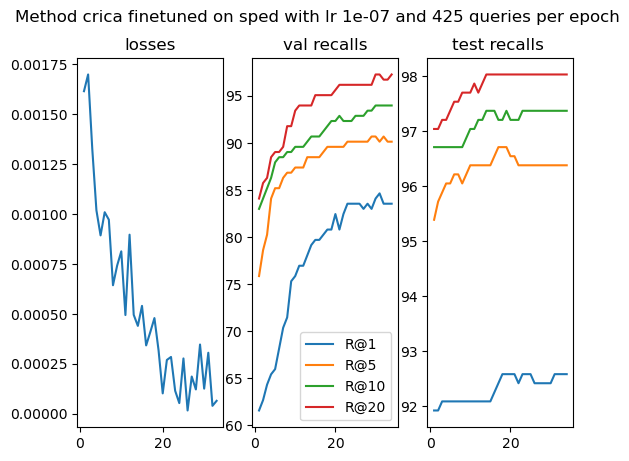

test recalls were [92.42174629 96.37561779 97.36408567 98.02306425] for the highest validation R@5
Original model results were [91.92751236 95.38714992 96.70510708 97.03459638] 
7
425
average epoch took0:00:57.029528 and median: 0:00:55.741016
training backbone: original with model.eval
training aggregator: True
augmentations: True


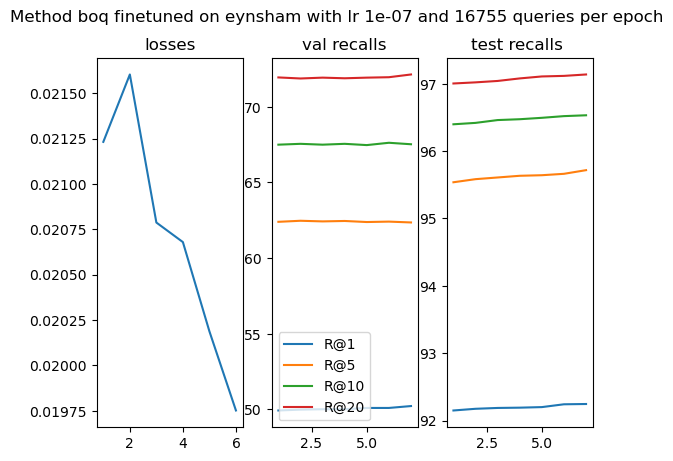

test recalls were [92.17463965 95.58387299 96.4194694  97.02109881] for the highest validation R@5
Original model results were [92.14957176 95.53791519 96.39857949 97.00438688] 
7
16755
average epoch took1:42:05.085884 and median: 1:42:54.916019
training backbone: original with model.eval
training aggregator: True
augmentations: True


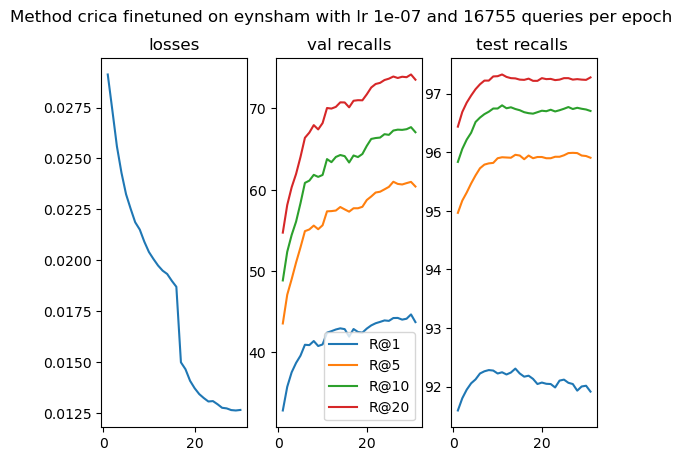

test recalls were [92.06601212 95.98495926 96.77041989 97.26342177] for the highest validation R@5
Original model results were [91.59390015 94.96553165 95.83455191 96.43618132] 
7
16755
average epoch took2:03:59.751074 and median: 2:03:55.191774
training backbone: original with model.eval
training aggregator: True
augmentations: True


In [67]:
train_datas=["gsv"]*8    
methods= ["boq", "crica"]*4
datasets=["nordland","nordland", "amstertime","amstertime","sped","sped","eynsham","eynsham"]
nums =   ["2",       "7",        "2",         "12",         "0",   "",    "2",      "2"]
    
for i, method in enumerate(methods): 
    train_data=train_datas[i]
    method=method
    dataset=datasets[i]
    lr=str(1e-7)
    num=nums[i]
    saved_path= f"logs/{train_data}_{method}/logfile{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
    # saved_path= "logs/gsv_crica/logfilegsv_crica_finetuned_on_nordland.pth1e-05"
    logfile=torch.load(saved_path)
    args=logfile['args']

    # 0 -> R@1 1 R@5 2 R@10 3 R@20
    recall_value=1
    show_num=-1
    recalls=np.array(logfile["recalls"])[:show_num]
    recall_orig=np.array([recalls[0]]*len(recalls))[:show_num]
    losses=logfile['losses']
    avg_losses=[np.average(loss) for loss in losses][:show_num]

    fig,[ax1,ax2,ax3]=plt.subplots(1,3)

    plt.suptitle(f"Method {method} finetuned on {dataset} with lr {lr} and {args.queries_per_epoch} queries per epoch")
    ax1.set_title("losses")
    title=["Recall@1","Recall@5","Recall@10","Recall@20"]
    ax2.set_title('val recalls')
    ax3.set_title("test recalls ")
    # ax1.set_ylim([0,max(avg_losses)*1.2])
    ax1.plot(np.linspace(1,len(avg_losses),len(avg_losses)),avg_losses)

    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,0])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,1])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,2])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,3])
    ax2.legend(["R@1","R@5","R@10","R@20"])
    tests=np.array(logfile["test_set_recalls"][:show_num])
    ax3.plot(np.linspace(1,len(tests),len(tests)),tests)

    s=0
    max_R5_val=np.argmax(recalls[:,1])
    # for s in range(0,4):
    #     print(f"for recall {recall_values[s]} the highest val is {max(recalls[:,s]):.2f} the highest test was {max(tests[:,s]):.2f} and the test R when max val was {tests[np.argmax(recalls[:,s])][s]:.2f}")

    args=logfile['args']
    fig.show()
    plt.show()
    
    print(f"test recalls were {tests[max_R5_val]} for the highest validation R@5")
    print(f"Original model results were {tests[0]} ")
    print(args.gpu_id)
    print(args.queries_per_epoch)
    if "times_per_epoch" in logfile.keys():
        times=np.array(logfile["times_per_epoch"])
        print(f"average epoch took{times.mean()} and median: {np.median(times)}")
    if "train_backbone" in args:
        print(f"training backbone: {args.train_backbone}")
        print(f"training aggregator: {args.train_aggregator}")
        print(f"augmentations: {args.augments}")

In [52]:
print(args.patience)

10


In [39]:
print(recalls[:,0].shape)

(1,)


In [33]:

def create_plot(method, dataset,lr=1e-7,num="",show_num=-1,dots=False,patience=None,print_shizzl=False):
    lr=str(lr)
    train_data='gsv'
    saved_path= f"logs/{train_data}_{method}/logfile{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
    # saved_path= "logs/gsv_crica/logfilegsv_crica_finetuned_on_nordland.pth1e-05"
    logfile=torch.load(saved_path)
    args=logfile['args']
    recall_value=1
    recalls=np.array(logfile["recalls"])[:show_num]
    recall_orig=np.array([recalls[0]]*len(recalls))[:show_num]
    losses=logfile['losses']
    avg_losses=[np.average(loss) for loss in losses][:show_num]

    fig,[ax1,ax2,ax3]=plt.subplots(1,3)

    plt.suptitle(f"Method {method} finetuned on {dataset} with lr {lr} and {args.queries_per_epoch} queries per epoch")
    ax1.set_title("losses")
    title=["Recall@1","Recall@5","Recall@10","Recall@20"]
    ax2.set_title('val recalls')
    ax3.set_title("test recalls ")
    # ax1.set_ylim([0,max(avg_losses)*1.2])
    ax1.plot(np.linspace(1,len(avg_losses),len(avg_losses)),avg_losses)

    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,0])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,1])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,2])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,3])
    ax2.legend(["R@1","R@5","R@10","R@20"])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,0])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,1])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,2])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,3])
    tests=np.array(logfile["test_set_recalls"][:show_num])
    # tests.insert(0,[91.2,96.2,97.5,98.5])

    # ax3.set_xticklabels([0,*logfile['best_epoch']])
    ax3.plot(np.linspace(1,len(tests),len(tests)),tests)

    # logfile["best_epoch"]
    r5_best=recalls[0][1]
    if print_shizzl:
        print("original patience was",args.patience)
    not_improved_num=0
    if patience !=None:    
        args.patience=patience
    early_stopping_val=None
    for i, recall_val in enumerate(recalls):


        r5_now= recall_val[1]
        if r5_now>r5_best:
            r5_best=r5_now
            early_stopping_val=i
            not_improved_num=0
        else:
            not_improved_num+=1

        if not_improved_num>(args.patience*np.ceil(args.queries_per_epoch/args.log_frequency)):
            
            break
        elif (i==len(recalls)-1 and r5_now==r5_best):
            print("not stopped earlier")

    print(early_stopping_val)
    if dots:
        ax3.scatter([early_stopping_val+1]*4,tests[early_stopping_val])
        ax2.scatter([early_stopping_val+1]*4,recalls[early_stopping_val])
    s=0
    max_R5_val=np.argmax(recalls[:,1])
    best_epoch=logfile["best_epoch"][-1]
    best_evaluation=np.argwhere(np.array(logfile["best_epoch"])==best_epoch)[0]
    if print_shizzl:
        print(f"test recalls were {tests[early_stopping_val]} for the highest validation R@5")
        print(f"Original model results were {tests[0]} ")
        print(f"best epoch num: {best_epoch}, based on a patience of {args.patience}")

        # # for s in range(0,4):
        #     print(f"for recall {recall_values[s]} the highest val is {max(recalls[:,s]):.2f} the highest test was {max(tests[:,s]):.2f} and the test R when max val was {tests[np.argmax(recalls[:,s])][s]:.2f}")

        print(args.lr)
        print(args.early_stopping,early_stopping_val)
        if "times_per_epoch" in logfile.keys():
            times=np.array(logfile["times_per_epoch"])
            print(f"average epoch took{times.mean()} and median: {np.median(times)}")
        if "train_backbone" in args:
            print(f"training backbone: {args.train_backbone}")
            print(f"training aggregator: {args.train_aggregator}")
            print(f"augmentations: {args.augments}")
            print(f"amount of loggings: {len(recalls)}")
            
        
    return avg_losses

In [ ]:
os.environ["CUDA_VISIBLE_DEVICES"]=str(6)

model=torch.hub.load("Lu-Feng/CricaVPR", "trained_model")
print(model)
model = torch.hub.load("serizba/salad", "dinov2_salad")
model = torch.hub.load("amaralibey/bag-of-queries", "get_trained_boq", backbone_name=args.backbone.lower(), output_dim=args.descriptors_dimension)

original patience was 5
132
test recalls were [92.40093428 96.64948454 97.81330541 98.63482603] for the highest validation R@5
Original model results were [88.62355026 94.86549613 96.54478093 97.73679124] 
best epoch num: 6, based on a patience of 5
1e-07
False 132
average epoch took3:53:33.815127 and median: 3:40:16.591749
training backbone: original with model.eval
training aggregator: True
augmentations: True
amount of loggings: 166
132


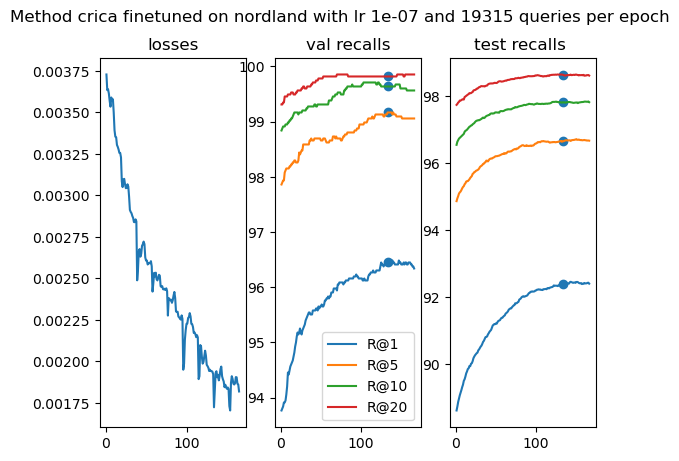

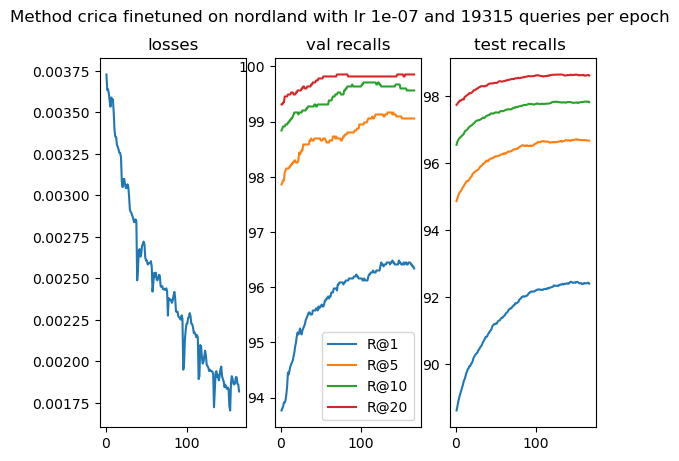

In [63]:
train_data='gsv'
method='crica'
dataset='nordland'
lr=1e-7
num="19"
num=16
patience=None

# 0 -> R@1 1 R@5 2 R@10 3 R@20

show_num=200

show_dots=True
x=create_plot(method,dataset,lr=lr,num=num,show_num=show_num,dots=show_dots,patience=patience,print_shizzl=True)
# x=create_plot(method,dataset,lr=lr,num=3,show_num=show_num,dots=show_dots,patience=patience,print_shizzl=True)
x=create_plot(method,dataset,lr=lr,num=num,show_num=show_num,dots=False,patience=patience,print_shizzl=False)

original patience was 15
68
test recalls were [64.90658002 83.83428107 87.57108042 90.90170593] for the highest validation R@5
Original model results were [62.6320065  81.55970755 85.54021121 88.54589764] 
best epoch num: 67, based on a patience of 15
1e-07
True 68
average epoch took0:03:36.455752 and median: 0:03:40.138258
training backbone: original with model.eval
training aggregator: True
augmentations: True
amount of loggings: 186
original patience was 5
14
test recalls were [63.93176279 83.02193339 86.5962632  89.60194963] for the highest validation R@5
Original model results were [62.6320065  81.55970755 85.54021121 88.54589764] 
best epoch num: 13, based on a patience of 5
1e-07
True 14
average epoch took0:05:41.564879 and median: 0:05:36.828132
training backbone: original with model.eval
training aggregator: True
augmentations: True
amount of loggings: 200


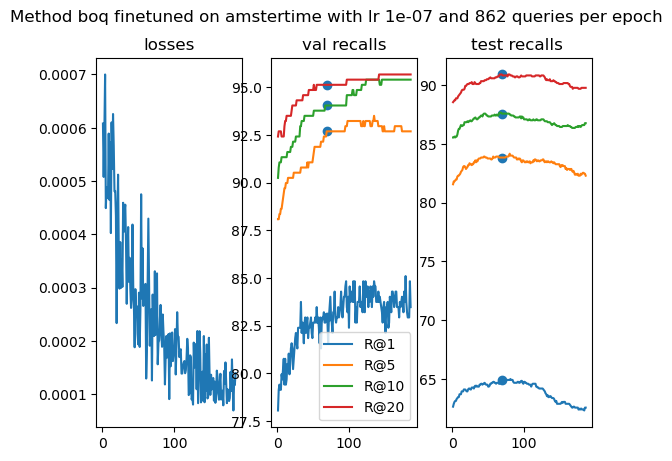

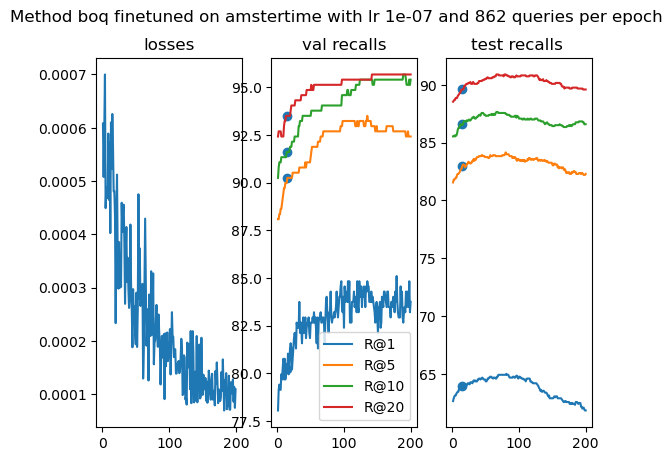

In [67]:
train_data='gsv'
method='boq'
dataset='sped'
num="1"

lr=1e-7
patience=None

# 0 -> R@1 1 R@5 2 R@10 3 R@20

show_num=-1
show_dots=False

loss1=create_plot(method,dataset,lr=lr,num=num,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot(method,dataset,lr=lr,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=True)


92
test recalls were [92.092257   96.37561779 97.19934102 97.69357496] for the highest validation R@5
Original model results were [91.92751236 95.38714992 96.70510708 97.03459638] 
best epoch num: 99, based on a patience of 30
1e-07
False 61
average epoch took0:02:10.845385 and median: 0:02:13.407230
training backbone: original with model.eval
training aggregator: True
augmentations: True
augmentations: True


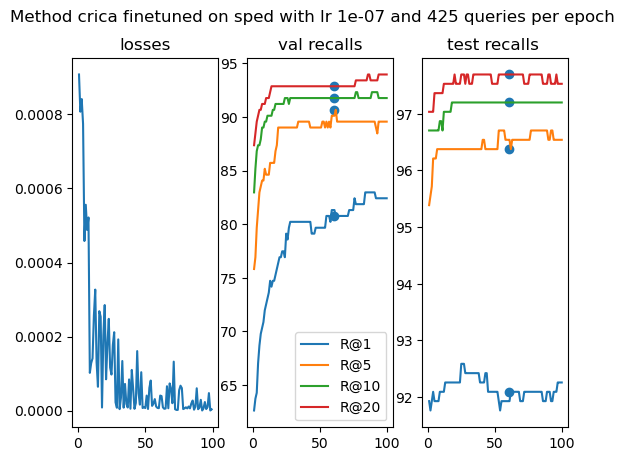

In [102]:
train_data='gsv'
method='crica'
dataset='sped'
lr=1e-7
num=1
patience=30

show_num=-1
show_dots=True

x=create_plot(method,dataset,lr=lr,num=num,show_num=show_num,dots=show_dots,patience=patience,print_shizzl=True)

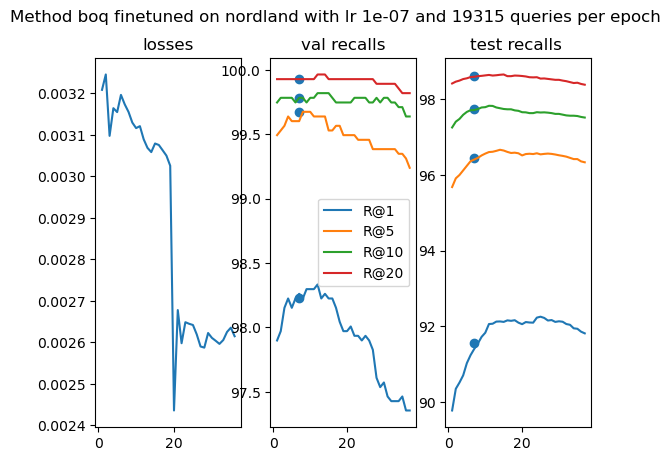

In [76]:
train_data='gsv'
method='boq'
dataset='nordland'
lr=1e-7
num="" # 1-6 3 1-7 
patience=5

# 0 -> R@1 1 R@5 2 R@10 3 R@20

show_num=-1
show_dots=True

x=create_plot(method,dataset,lr=lr,num=num,show_num=show_num,dots=show_dots,patience=patience)